# Распознавание эмоций людей по фото


![Image](https://d26oc3sg82pgk3.cloudfront.net/files/media/edit/image/47054/article_featured%403x.jpg)


## Загрузка данных


1. Определяем две переменные `data_train` и `data_test`, которые содержат пути к файлам с обучающими и тестовыми наборами данных соответственно.

2. Далее определяем функцию `convert_df`, преобразующую набор данных в объект pandas DataFrame. На вход функция `convert_df` принимает один аргумент — путь к файлу с набором данных.

3. Внутри функции `convert_df` первая строка `img_dir = Path(dataset)` преобразует путь к набору данных в объект `Path` с помощью функции `Path` из модуля `pathlib`, предоставляющего удобный способ обработки путей к файлам в Python.

4. Затем код использует `glob` для поиска всех файлов с расширением «.jpg» в каталоге набора данных и его подкаталогах. Команда `filename = list(img_dir.glob(r'*/.jpg'))` возвращает список всех путей к файлам, которые соответствуют указанному шаблону.

5. Получив список путей к файлам (`filename`) и соответствующие им метки (`label`), код преобразует их в объект pandas Series с помощью pd.Series.

6. Функция `pd.concat()` используется для объединения двух серий (`filename` и `label`) вдоль столбцов (ось=1), создавая DataFrame с именем `image_df`. Этот DataFrame будет иметь два столбца: «*Filepath*» и «*Label*».

7. Функция `convert_df` возвращает результирующий DataFrame `image_df`.

8. Наконец, дважды вызываем функцию `convert_df` с путями `data_train` и `data_test` соответственно для создания двух DataFrames: `image_train` и `image_test`.

Подводя итог, можно сказать, что этот код берет пути к файлам изображений в обучающих и тестовых наборах данных, извлекает их соответствующие метки и организует их в pandas DataFrames для дальнейшей обработки или анализа.


In [25]:
# !pip install opendatasets

Данные загружаются локально из zip-архивов, которые лежат рядом с блокнотом.


In [26]:
import os, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

IMAGE_EXTS = ('*.jpg', '*.jpeg', '*.png')
data_dir = Path('data')
data_dir.mkdir(exist_ok=True)

if not any(file for ext in IMAGE_EXTS for file in data_dir.glob(f'**/{ext}')):
    for archive in Path('.').glob('*.zip'):
        with zipfile.ZipFile(archive) as zf:
            zf.extractall(data_dir)


def convert_img_to_df(dataset):
    files = [file for ext in IMAGE_EXTS for file in Path(dataset).glob(f'**/{ext}')]
    df = pd.DataFrame({'Filepath': [str(file) for file in files],
                       'Label': [file.parent.name for file in files]})
    return df.sample(frac=1, random_state=42).reset_index(drop=True)

img_df = convert_img_to_df(data_dir)
assert not img_df.empty, 'Images were not found. Check that zip archives are in the notebook folder.'
img_df.head()


,Filepath,Label
0,data\Happy\10-Habits-of-Happy-People-Seniors-T...,Happy
1,data\Sad\sad-people-icon-2CCHXB2.jpg,Sad
2,data\Happy\afro-girl-enjoying-the-sea-idyll-ro...,Happy
3,data\Angry\Angry-Person-PNG-Transparent-Image.png,Angry
4,data\Happy\happy-people-jump-with-raised-arms-...,Happy


<small>Таблица показывает первые строки собранного DataFrame: для каждого изображения сохранены путь к файлу и метка класса. Мы получили записи из разных папок (`Happy`, `Sad`, `Angry`), потому что метка берется из названия родительской папки, а затем данные перемешиваются перед дальнейшей обработкой.</small>


Проверим форму изображения


In [27]:
img = plt.imread(img_df['Filepath'].iloc[1])
img.shape

(1390, 1300, 3)

<small>Размер `(1390, 1300, 3)` означает: высота изображения 1390 пикселей, ширина 1300 пикселей и 3 цветовых канала RGB. Это подтверждает, что исходные изображения цветные, но их размеры не унифицированы, поэтому дальше генераторы приводят все картинки к одному размеру `224x224`.</small>


## Краткий обзор распределения меток изображений


Создаем круговую и столбчатую диаграмму для визуализации процента и количества каждой метки изображения соответственно.


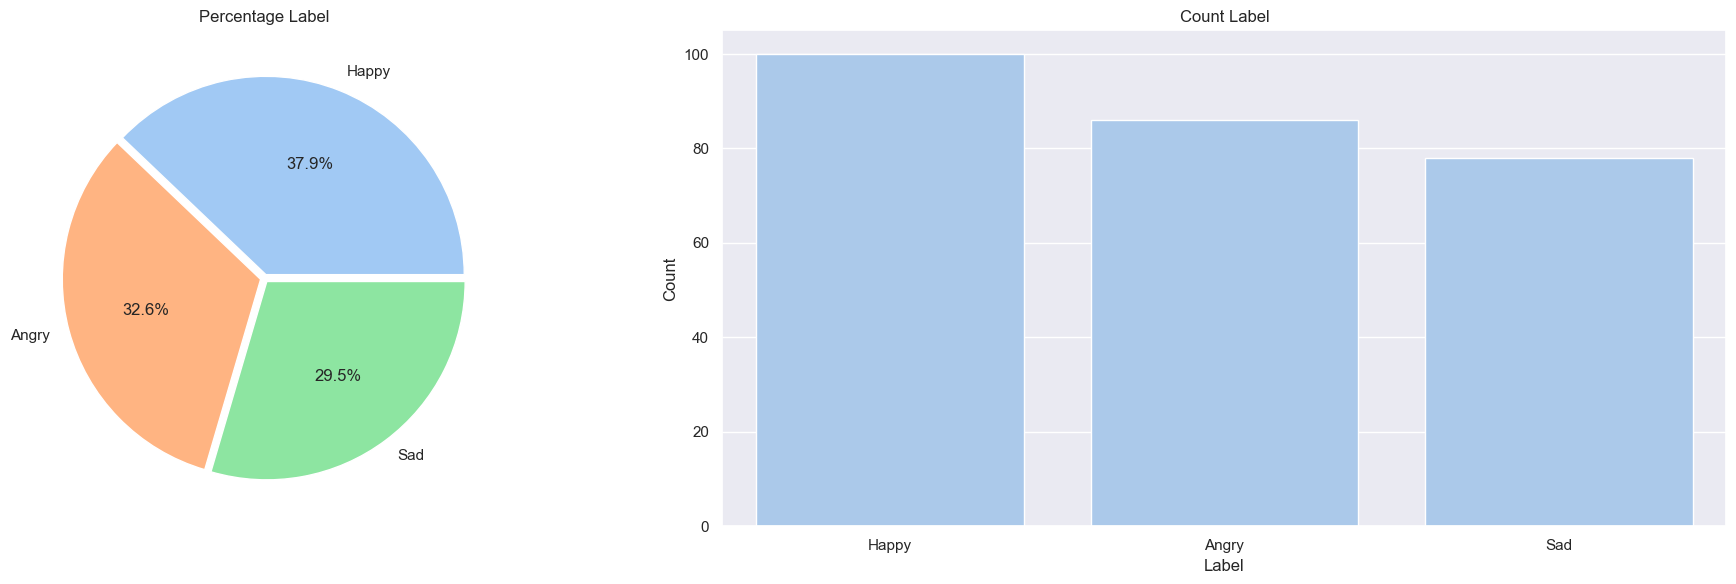

In [28]:
# Количество меток
label_count = img_df['Label'].value_counts()

# Настройки
fig,axes = plt.subplots(nrows=1, ncols=2, figsize=(20,6))
sns.set_theme(style='darkgrid', palette='pastel')
color = sns.color_palette(palette='pastel')
explode = [0.02]*len(label_count)

# Круговая диаграмма
axes[0].pie(label_count.values, labels=label_count.index, autopct='%1.1f%%', colors=color, explode=explode)
axes[0].set_title('Percentage Label')

# Столбчатая диаграмма
sns.barplot(x=label_count.index, y=label_count.values, ax=axes[1])
axes[1].set_title('Count Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')

# Отображаем
plt.tight_layout()
plt.show()

<small>Диаграммы показывают распределение классов: в текущем наборе больше всего изображений `Happy`, затем идут `Angry` и `Sad`. Такое распределение не идеально равномерное, поэтому модель может чаще выбирать более представленный класс; из-за этого при разбиении данных важно сохранять пропорции классов.</small>


## Показ изображения


Генерируем сетку 4x4 случайных изображений из DataFrame `image_train` и отображает их с соответствующими метками в качестве заголовков.
Разберем код по шагам:

**1. `random_index = np.random.randint(0, len(image_train), 16)`:** Эта строка генерирует массив из 16 случайных целых чисел в диапазоне от 0 до количества строк в DataFrame `image_train`. Функция `np.random.randint` из библиотеки NumPy используется здесь для выбора 16 случайных индексов из DataFrame.

**2. `fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10), subplot_kw={'xticks': [], 'yticks': []})`:** Эта строка создает сетку 4x4 подграфиков с помощью функции `subplots` библиотеки Matplotlib. Переменная `fig` представляет всю фигуру, а переменная `axes` — это массив объектов Axes, соответствующих каждому подграфику. Параметр `subplot_kw` используется для задания свойств подграфиков, в данном случае для удаления отметок осей x и y.

**3. Следующий блок кода использует цикл для итерации по сетке 4x4 подграфиков и отображения изображений вместе с их метками:**

- `enumerate(axes.flat)` генерирует пары `(index, ax)` для каждого подучастка в массиве осей. Функция `enumerate` используется для циклического прохода по подучасткам, отслеживая при этом индекс и соответствующий объект подучастка (`ax`).
- `img = plt.imread(image_train['Filepath'].iloc[random_index[i]])`: Эта строка считывает изображение, соответствующее случайному индексу `random_index[i]`, из DataFrame `image_train` с помощью функции `plt.imread` из Matplotlib.
- `ax.imshow(img)`: отображение изображения на оси текущего подграфика.
1. `ax.set_title(image_train['Label'].iloc[random_index[i]])`: устанавливает заголовок текущего подграфика в соответствии с меткой соответствующего изображения из DataFrame `image_train`.
2. `plt.tight_layout()`: Эта строка гарантирует, что `subplots` правильно расположены внутри рисунка, чтобы избежать перекрытия.


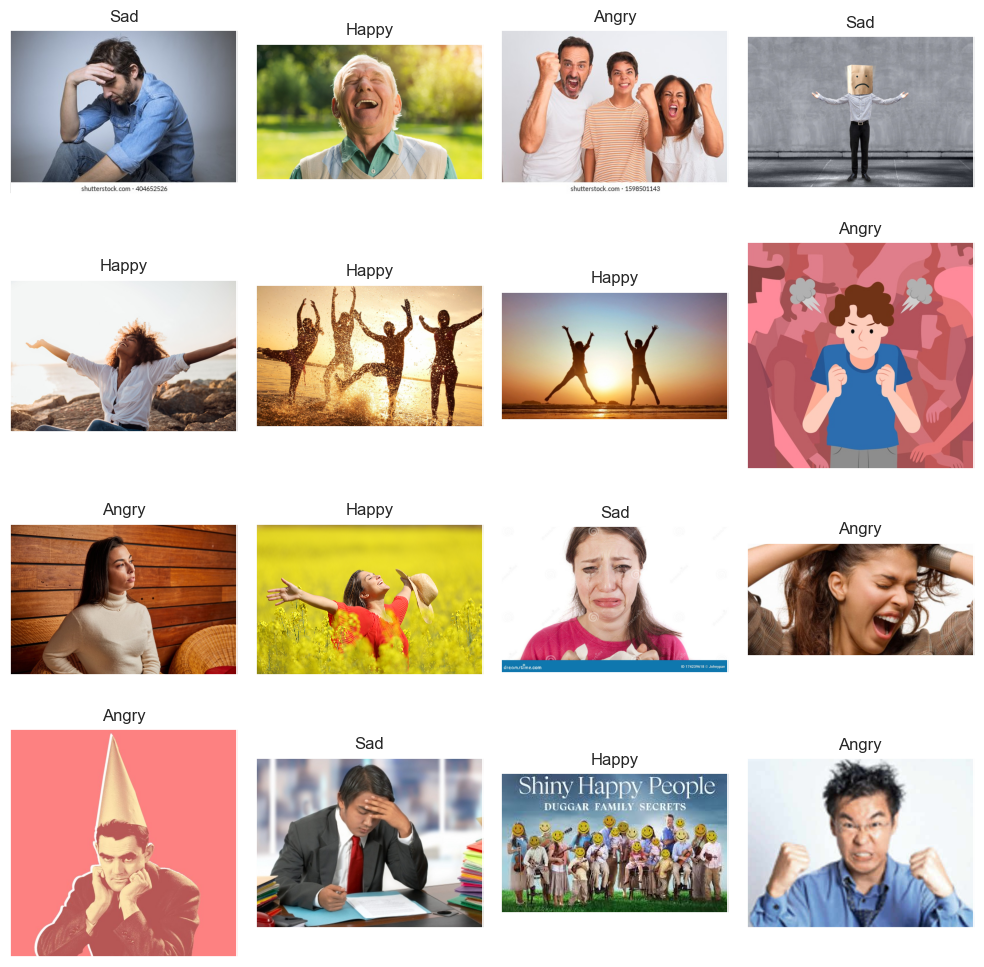

In [29]:
random_index = np.random.randint(0,len(img_df),16)
fig,axes = plt.subplots(nrows=4,ncols=4,figsize=(10,10),subplot_kw={'xticks':[],'yticks':[]})

for i,ax in enumerate(axes.flat):
  img = plt.imread(img_df['Filepath'].iloc[random_index[i]])
  ax.imshow(img)
  ax.set_title(img_df['Label'].iloc[random_index[i]])
plt.tight_layout()
plt.show()

<small>Сетка показывает случайные изображения и их подписи. Видно, что картинки отличаются стилем, качеством и композицией, потому что датасет собран из разных источников; такая вариативность делает обучение сложнее, но помогает модели искать более общие признаки эмоций.</small>


Подготовка обучающих и проверочных наборов данных для модели глубокого обучения с использованием Keras ImageDataGenerator. Она включает в себя разделение DataFrame `image_train` на обучающие и проверочные наборы и настройку генераторов данных для обработки изображений во время обучения.


**1. train, val** = train_test_split(image_train, test_size=0.2): Эта строка использует функцию `train_test_split` из `scikit-learn` для разделения DataFrame` image_train` на две части: train и val (валидация). Аргумент `test_size=0.2` указывает, что 20% данных будут использоваться для проверки, а оставшиеся 80% — для обучения.

**2. datagen** = ImageDataGenerator(rescale=1./255): Здесь создается объект `ImageDataGenerator`, который будет использоваться для дополнения изображений во время обучения и проверки. Аргумент `rescale=1./255` масштабирует значения пикселей изображений от 0 до 1, что является обычной практикой для нейронных сетей, использующих данные в виде изображений.

**3. Настройка генераторов данных:**

- `train_set`: Этот генератор данных создан с использованием `datagen.flow_from_dataframe()` для потока данных изображений из DataFrame train. Он принимает пути файлов ('Filepath') и соответствующие метки ('Label') в качестве входных данных. Генератор выдает пакеты из 32 изображений за раз (`batch_size=32`), а метки представлены в категориальном формате (`class_mode='categorical'`).
- `val_set`: Этот генератор данных похож на train_set, но создан для проверочных данных (DataFrame val).

**4. Аргументы, используемые в flow_from_dataframe:**

- `dataframe`: DataFrame, из которого загружаются данные.
- `x_col`: имя столбца в DataFrame, содержащего пути к файлам изображений.
- `y_col`: имя столбца в DataFrame, содержащего метки.
- `batch_size`: количество образцов в каждой партии (batch).
- `class_mode`: тип предоставленных меток; «категориальный» указывает на то, что метки кодируются напрямую для многоклассовой классификации..
- `seed`: случайное начальное число для перемешивания и преобразования данных.
- `shuffle`: нужно ли перемешивать данные в начале каждой эпохи.
- `target_size`: размер, до которого будут изменены все изображения в процессе загрузки..


In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPool2D, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image

np.random.seed(42)
tf.random.set_seed(42)
tf.get_logger().setLevel('ERROR')


In [31]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_train, test = train_test_split(img_df, test_size=0.1, random_state=42, stratify=img_df['Label'])
train, val = train_test_split(img_train, test_size=0.2, random_state=42, stratify=img_train['Label'])


def make_image_sets(batch_size=32, preprocessing=None):
    prep = {'preprocessing_function': preprocessing} if preprocessing else {'rescale': 1./255}
    train_gen = ImageDataGenerator(**prep, rotation_range=10, width_shift_range=0.1,
                                   height_shift_range=0.1, zoom_range=0.1,
                                   horizontal_flip=True)
    test_gen = ImageDataGenerator(**prep)
    common = dict(x_col='Filepath', y_col='Label', target_size=(224, 224),
                  batch_size=batch_size, class_mode='categorical')
    train_set = train_gen.flow_from_dataframe(train, shuffle=True, seed=42, **common)
    val_set = test_gen.flow_from_dataframe(val, shuffle=True, seed=42, **common)
    test_set = test_gen.flow_from_dataframe(test, shuffle=False, seed=42, **common)
    return train_set, val_set, test_set

train_set, val_set, test_set = make_image_sets(batch_size=32)


Found 189 validated image filenames belonging to 3 classes.
Found 48 validated image filenames belonging to 3 classes.
Found 27 validated image filenames belonging to 3 classes.


<small>Генераторы нашли 189 изображений для обучения, 48 для валидации и 27 для теста, при этом во всех трех наборах присутствуют 3 класса. Такие числа получились из разбиения всего набора: сначала выделяется тестовая часть, затем из оставшихся данных отделяется валидационная выборка.</small>


## Модель


Зададим компактную функцию сборки CNN, чтобы менять `batch_size`, число сверточных блоков, число нейронов Dense-слоя, оптимизатор и `learning rate`. После короткого подбора лучшая конфигурация по `val_accuracy` используется для финального обучения.


### Подбор гиперпараметров CNN
Проверим несколько компактных конфигураций и выберем лучшую по валидационной точности.


In [32]:
def build_cnn(filters=(16, 32), dense_units=128, lr=1e-4, optimizer_name='adam'):
    model = Sequential([Input(shape=(224, 224, 3)),
                        Conv2D(filters[0], 3, activation='relu', padding='same'),
                        MaxPool2D(2)])
    for f in filters[1:]:
        model.add(Conv2D(f, 3, activation='relu', padding='same'))
        model.add(MaxPool2D(2))
    model.add(Flatten())
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(0.45))
    model.add(Dense(3, activation='softmax'))
    opt = Adam(learning_rate=lr) if optimizer_name == 'adam' else RMSprop(learning_rate=lr)
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

cnn_search = [
    dict(batch_size=16, epochs=5, optimizer_name='adam', lr=1e-3, filters=(16, 32), dense_units=128),
    dict(batch_size=32, epochs=7, optimizer_name='adam', lr=1e-4, filters=(16, 32, 64), dense_units=128),
    dict(batch_size=32, epochs=7, optimizer_name='rmsprop', lr=1e-4, filters=(32, 64), dense_units=256),
]

cnn_results = []
for params in cnn_search:
    K.clear_session()
    train_set, val_set, _ = make_image_sets(params['batch_size'])
    cb = [EarlyStopping(monitor='val_accuracy', mode='max', patience=2, restore_best_weights=True)]
    h = build_cnn(params['filters'], params['dense_units'], params['lr'], params['optimizer_name']).fit(
        train_set, validation_data=val_set, epochs=params['epochs'], callbacks=cb, verbose=0)
    cnn_results.append({**params, 'trained_epochs': len(h.history['loss']),
                        'val_accuracy': max(h.history['val_accuracy']),
                        'val_loss': min(h.history['val_loss'])})

cnn_results = pd.DataFrame(cnn_results).sort_values('val_accuracy', ascending=False)
best_cnn_params = {k: cnn_results.iloc[0][k] for k in cnn_search[0]}
best_cnn_params.update(batch_size=int(best_cnn_params['batch_size']),
                       epochs=20,
                       dense_units=int(best_cnn_params['dense_units']))
cnn_results


Found 189 validated image filenames belonging to 3 classes.
Found 48 validated image filenames belonging to 3 classes.
Found 27 validated image filenames belonging to 3 classes.
Found 189 validated image filenames belonging to 3 classes.
Found 48 validated image filenames belonging to 3 classes.
Found 27 validated image filenames belonging to 3 classes.
Found 189 validated image filenames belonging to 3 classes.
Found 48 validated image filenames belonging to 3 classes.
Found 27 validated image filenames belonging to 3 classes.


,batch_size,epochs,optimizer_name,lr,filters,dense_units,trained_epochs,val_accuracy,val_loss
0,16,5,adam,0.0010,"(16, 32)",128,5,0.541667,1.073748
2,32,7,rmsprop,0.0001,"(32, 64)",256,6,0.500000,1.052568
1,32,7,adam,0.0001,"(16, 32, 64)",128,5,0.458333,1.037139


<small>Для каждой проверяемой конфигурации CNN заново создаются генераторы данных, поэтому сообщения `Found ...` повторяются несколько раз. Таблица отсортирована по валидационной точности: лучшей среди проверенных стала компактная CNN с `batch_size=16`, `Adam`, `lr=0.001` и фильтрами `(16, 32)`, но разница между вариантами небольшая из-за малого размера датасета и короткого обучения.</small>


In [33]:
K.clear_session()
model = build_cnn(best_cnn_params['filters'],
                  best_cnn_params['dense_units'],
                  best_cnn_params['lr'],
                  best_cnn_params['optimizer_name'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,850,659 (49.02 MB)

 Trainable params: 12,850,659 (49.02 MB)

 Non-trainable params: 0 (0.00 B)

<small>Сводка модели показывает выбранную архитектуру CNN и количество параметров: всего около 12.85 млн обучаемых параметров. Основная часть параметров появляется после слоя `Flatten`, где карты признаков превращаются в длинный вектор для полносвязного слоя; необучаемых параметров нет, потому что здесь не используется замороженная предобученная база.</small>


Обучаем CNN с гиперпараметрами, сохраненными в `best_cnn_params`.


In [34]:
cnn_train_set, cnn_val_set, cnn_test_set = make_image_sets(batch_size=best_cnn_params['batch_size'])
cnn_callbacks = [EarlyStopping(monitor='val_accuracy', mode='max', patience=6, restore_best_weights=True),
                 ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)]
history = model.fit(cnn_train_set, validation_data=cnn_val_set,
                    epochs=best_cnn_params['epochs'], callbacks=cnn_callbacks, verbose=1)


Found 189 validated image filenames belonging to 3 classes.
Found 48 validated image filenames belonging to 3 classes.
Found 27 validated image filenames belonging to 3 classes.
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 688ms/step - accuracy: 0.2910 - loss: 5.2111 - val_accuracy: 0.3750 - val_loss: 1.0937 - learning_rate: 0.0010
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 519ms/step - accuracy: 0.3175 - loss: 1.1152 - val_accuracy: 0.3750 - val_loss: 1.0611 - learning_rate: 0.0010
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 542ms/step - accuracy: 0.3757 - loss: 1.0604 - val_accuracy: 0.3750 - val_loss: 1.0720 - learning_rate: 0.0010
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 544ms/step - accuracy: 0.3968 - loss: 1.0393 - val_accuracy: 0.3750 - val_loss: 1.0483 - learning_rate: 0.0010
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 560ms/step - accuracy: 0.3968 - loss: 1.0122 - val_accuracy: 0.3750 - val_loss: 1.0947 - learning_rate: 0.0010
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 535ms/step - accurac

<small>Во время обучения точность CNN постепенно растет, а `learning_rate` уменьшается, когда валидационная ошибка перестает улучшаться. Обучение завершилось раньше максимальных 20 эпох из-за `EarlyStopping`: валидационная точность вышла на плато примерно около 0.60, поэтому дальнейшие эпохи уже почти не давали прироста.</small>


Генерируем рядом два подграфика для визуализации производительности обучения и валидации модели. Затем оцениваем модель на тестовом наборе данных с помощью метода оценки.


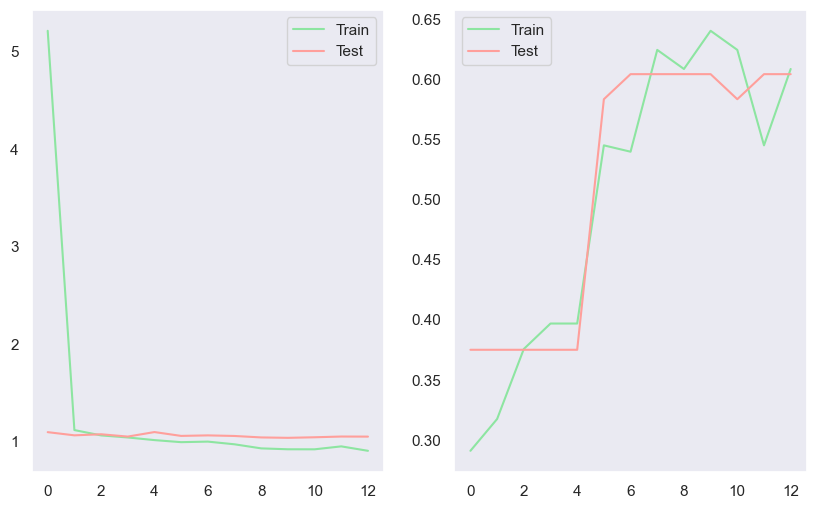

In [35]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='Train',c='g')
plt.plot(history.history['val_loss'],label='Test',c='r')
plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],label='Train',c='g')
plt.plot(history.history['val_accuracy'],label='Test',c='r')
plt.grid()
plt.legend()
plt.show()

<small>Графики показывают динамику ошибки и точности на обучающей и валидационной выборках. Ошибка в целом снижается, а точность стабилизируется около 0.58-0.60; это значит, что CNN выучила часть признаков эмоций, но качество ограничено небольшим и неоднородным набором данных.</small>


In [36]:
cnn_score = model.evaluate(cnn_test_set, steps=len(cnn_test_set), verbose=0)
print('CNN Loss: {:.2f}'.format(cnn_score[0]))
print('CNN Accuracy: {:.2f}'.format(cnn_score[1]))


CNN Loss: 1.05
CNN Accuracy: 0.52


<small>На тестовой выборке CNN получила `loss = 1.05` и `accuracy = 0.52`, то есть правильно классифицировала примерно половину изображений. Это выше случайного угадывания для трех классов, но результат все еще умеренный: модели не хватает данных и устойчивых признаков для надежного распознавания всех эмоций.</small>


## Предварительно обученная модель


Предварительно обученная модель — это модель глубокого обучения, предварительно обученная на большом наборе данных для решения определенной задачи, такой как распознавание изображений, обработка естественного языка или обнаружение объектов. Эти модели обычно обучаются на мощном оборудовании и больших наборах данных в течение длительного периода.

**Ключевые характеристики предварительно обученных моделей:**

1. Transfer Learning (перенос обучения): Предварительно обученные модели служат отправной точкой для новых задач машинного обучения. Вместо обучения модели с нуля на новом наборе данных, перенос обучения позволяет нам использовать знания и представления, полученные предварительно обученной моделью, для решения другой, но связанной проблемы. Такой подход может значительно сократить объем данных и время, необходимое для обучения, и может быть очень эффективным, особенно когда новый набор данных невелик.

2. Feature Extraction (извлечение признаков): предварительно обученные модели являются мощными извлекателями признаков. Они учатся определять низкоуровневые и высокоуровневые признаки в данных, такие как края, текстуры и формы объектов. Более ранние слои предварительно обученной модели захватывают признаки, которые являются общими для многих наборов данных, в то время как более поздние слои захватывают более конкретные признаки, связанные с исходной задачей, на которой обучалась модель.

3. Model Architectures (архитектуры моделей): предварительно обученные модели часто поставляются с популярными и сложными архитектурами, такими как VGG, ResNet, Inception, BERT, GPT и т. д. Эти архитектуры разрабатывались и совершенствовались исследователями с течением времени и показали высокую производительность при выполнении различных контрольных задач.

4. Availability (доступность): многие предварительно обученные модели, особенно для задач компьютерного зрения и обработки естественного языка, доступны как часть популярных фреймворков глубокого обучения, таких как TensorFlow, Keras, PyTorch и библиотека Transformers от Hugging Face. Это упрощает для исследователей и разработчиков использование возможностей этих моделей в своих проектах.


## VGG16


Используем Keras для импорта предварительно обученной модели VGG16 и настройки ImageDataGenerator с функцией предварительной обработки.

**1. from keras.applications.vgg16 import VGG16, preprocess_input:** эта строка импортирует предварительно обученную модель VGG16 из Keras и функцию `preprocess_input`, которая используется для предварительной обработки входных изображений перед передачей их в модель VGG16.

**2. datagen = ImageDataGenerator(preprocessing_function=preprocess_input):** эта строка устанавливает объект `ImageDataGenerator` с функцией `preprocess_input` в качестве `preprocessing_function`. `ImageDataGenerator` — это мощная утилита в Keras, которая позволяет на лету дополнять данные и выполнять предварительную обработку изображений во время обучения модели.

Функция `preprocess_input` используется специально для модели VGG16. Она применяет соответствующую предварительную обработку к изображениям для соответствия формату, на котором обучалась модель VGG16. Предварительная обработка обычно включает масштабирование значений пикселей до определенного диапазона и нормализацию по каналам.

Используя `ImageDataGenerator` с функцией `preprocess_input`, можно передавать изображения в модель VGG16 в режиме реального времени с надлежащей предварительной обработкой, что делает ее удобной для задач классификации изображений и трансферного обучения.


In [37]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

vgg_params = dict(batch_size=32, dense_units=256, dropout=0.4,
                  lr=1e-4, epochs=12, fine_tune_lr=1e-5, fine_tune_epochs=8)
vgg_train_set, vgg_val_set, vgg_test_set = make_image_sets(batch_size=vgg_params['batch_size'],
                                                           preprocessing=preprocess_input)


Found 189 validated image filenames belonging to 3 classes.
Found 48 validated image filenames belonging to 3 classes.
Found 27 validated image filenames belonging to 3 classes.


<small>Для VGG16 получились те же размеры выборок: 189 обучающих, 48 валидационных и 27 тестовых изображений. Отличие от CNN в том, что теперь используется `preprocess_input`, который приводит пиксели к формату, ожидаемому предобученной VGG16.</small>


Используем трансферное обучение для создания новой модели, используя предварительно обученную модель VGG16 для извлечения признаков.

**1. base_vgg = VGG16(weights='imagenet', input_shape=(224, 224, 3), include_top=False):** эта строка загружает модель VGG16 с весами, предварительно обученными на наборе данных ImageNet. Параметр `input_shape` установлен на (224, 224, 3) для соответствия размеру входных данных модели VGG16, предполагая, что изображения RGB имеют размер 224x224 пикселей. Аргумент `include_top=False` означает, что последние полностью связанные слои (слои классификации) модели VGG16 не будут включены в загруженную модель.

**2. base_vgg.trainable = False:** эта строка замораживает веса базовой модели VGG16, чтобы они не поддавались обучению в процессе тонкой настройки. Этот шаг необходим для того, чтобы предварительно обученные веса VGG16 не обновлялись во время обучения новой модели, предотвращая их переобучение для новой задачи.


**Model**


In [38]:
base_vgg = VGG16(weights='imagenet', input_shape=(224, 224, 3), include_top=False)
base_vgg.trainable = False

vgg_model = Sequential([base_vgg,
                        GlobalAveragePooling2D(),
                        Dense(vgg_params['dense_units'], activation='relu'),
                        Dropout(vgg_params['dropout']),
                        Dense(3, activation='softmax')])

vgg_model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=vgg_params['lr']),
                  metrics=['accuracy'])


**Compile & Train**


In [39]:
vgg_callbacks = [EarlyStopping(monitor='val_accuracy', mode='max', patience=4, restore_best_weights=True),
                 ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)]
history_vgg = vgg_model.fit(vgg_train_set, validation_data=vgg_val_set,
                            epochs=vgg_params['epochs'], callbacks=vgg_callbacks, verbose=1)

vgg_frozen_score = vgg_model.evaluate(vgg_test_set, steps=len(vgg_test_set), verbose=0)
print('Frozen VGG16 Loss: {:.2f}'.format(vgg_frozen_score[0]))
print('Frozen VGG16 Accuracy: {:.2f}'.format(vgg_frozen_score[1]))


Epoch 1/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.3439 - loss: 4.4282 - val_accuracy: 0.4375 - val_loss: 2.1311 - learning_rate: 1.0000e-04
Epoch 2/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.4180 - loss: 3.7500 - val_accuracy: 0.5625 - val_loss: 1.8648 - learning_rate: 1.0000e-04
Epoch 3/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.4656 - loss: 3.4923 - val_accuracy: 0.5417 - val_loss: 1.7313 - learning_rate: 1.0000e-04
Epoch 4/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.4497 - loss: 2.8842 - val_accuracy: 0.5208 - val_loss: 1.6312 - learning_rate: 1.0000e-04
Epoch 5/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.5026 - loss: 2.6376 - val_accuracy: 0.5625 - val_loss: 1.5601 - learning_rate: 1.0000e-04
Epoch 6/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.4815 - loss: 2.3881 - val_accuracy: 0.6042 - val_loss: 1.5528 - learning_rate: 1.0000e-04
Epoch 7/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.5238 - loss: 2.1887 - val_

<small>На первом этапе VGG16 обучается с замороженной сверточной базой: меняется только новый классификатор сверху. Валидационная точность доходит примерно до 0.60, но тестовая точность равна 0.48; предобученные признаки помогают, однако небольшой датасет и отличие наших изображений от ImageNet ограничивают качество.</small>


### Тонкая настройка VGG16
Разморозим последние сверточные слои VGG16 и продолжим обучение с маленьким `learning rate`.


In [40]:
fine_tune_layers = {'block5_conv1', 'block5_conv2', 'block5_conv3'}
base_vgg.trainable = True
for layer in base_vgg.layers:
    layer.trainable = layer.name in fine_tune_layers

vgg_model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=vgg_params['fine_tune_lr']),
                  metrics=['accuracy'])
fine_callbacks = [EarlyStopping(monitor='val_accuracy', mode='max', patience=3, restore_best_weights=True)]
history_vgg_fine = vgg_model.fit(vgg_train_set, validation_data=vgg_val_set,
                                 epochs=vgg_params['fine_tune_epochs'], callbacks=fine_callbacks, verbose=1)

for key, value in history_vgg_fine.history.items():
    history_vgg.history.setdefault(key, []).extend(value)


Epoch 1/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.4497 - loss: 2.2378 - val_accuracy: 0.5833 - val_loss: 1.4067
Epoch 2/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5503 - loss: 2.0879 - val_accuracy: 0.5833 - val_loss: 1.2802
Epoch 3/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.5608 - loss: 1.4005 - val_accuracy: 0.6042 - val_loss: 1.2038
Epoch 4/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5873 - loss: 1.3817 - val_accuracy: 0.5833 - val_loss: 1.1333
Epoch 5/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.5873 - loss: 1.2390 - val_accuracy: 0.5833 - val_loss: 1.0883
Epoch 6/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6772 - loss: 0.8871 - val_accuracy: 0.5833 - val_loss: 1.0653


<small>При тонкой настройке разморожены последние сверточные слои VGG16, поэтому модель начинает адаптировать признаки под наш датасет. Ошибка уменьшается, а обучающая точность растет, но валидационная точность остается примерно на том же уровне, что указывает на риск переобучения при малом числе изображений.</small>


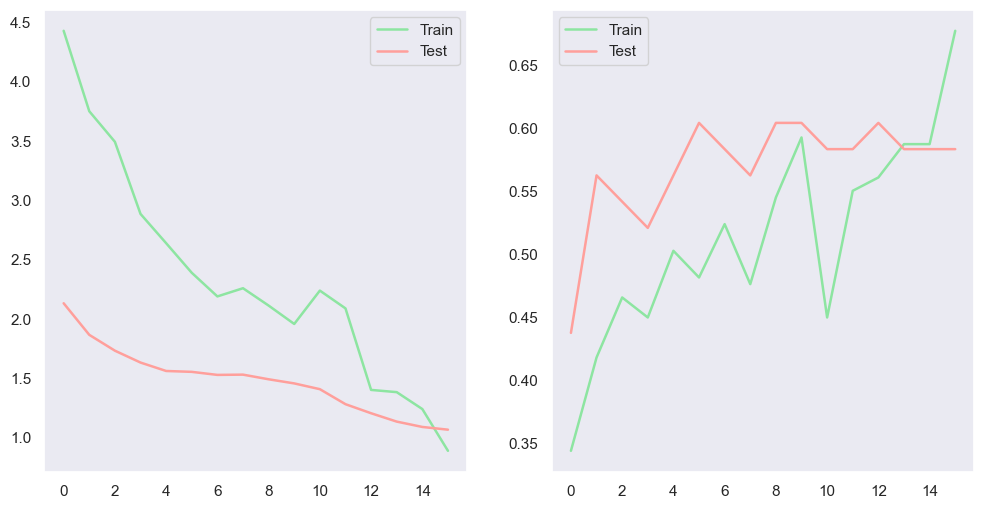

In [41]:
sns.set_theme(style='darkgrid',palette='pastel')
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(history_vgg.history['loss'],label='Train',c='g',lw=1.8)
plt.plot(history_vgg.history['val_loss'],label='Test',c='r',lw=1.8)
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history_vgg.history['accuracy'],label='Train',c='g',lw=1.8)
plt.plot(history_vgg.history['val_accuracy'],label='Test',c='r',lw=1.8)
plt.legend()
plt.grid()

plt.show()

<small>Графики объединяют историю обучения VGG16 до и после тонкой настройки. Видно, что loss постепенно снижается, но валидационная accuracy колеблется около одного уровня; это объясняет, почему более сложная модель не дала уверенного прироста на тесте.</small>


In [42]:
vgg_score = vgg_model.evaluate(vgg_test_set, steps=len(vgg_test_set), verbose=0)
print('VGG16 Loss: {:.2f}'.format(vgg_score[0]))
print('VGG16 Accuracy: {:.2f}'.format(vgg_score[1]))


VGG16 Loss: 1.96
VGG16 Accuracy: 0.41


<small>После тонкой настройки VGG16 получила `loss = 1.96` и `accuracy = 0.41` на тестовой выборке. Результат оказался ниже, чем у замороженной VGG16 и CNN, потому что дополнительное обучение последних слоев на маленьком наборе могло ухудшить обобщающую способность модели.</small>


### Сравнение моделей


In [43]:
final_results = pd.DataFrame([
    ['CNN tuned', cnn_score[0], cnn_score[1], len(history.history['loss']), str(best_cnn_params)],
    ['VGG16 frozen', vgg_frozen_score[0], vgg_frozen_score[1], len(history_vgg.history['loss']) - len(history_vgg_fine.history['loss']), str(vgg_params)],
    ['VGG16 fine-tuned', vgg_score[0], vgg_score[1], len(history_vgg.history['loss']), f"{vgg_params}, unfrozen={sorted(fine_tune_layers)}"]
], columns=['model', 'test_loss', 'test_accuracy', 'trained_epochs', 'used_hyperparameters'])
final_results


,model,test_loss,test_accuracy,trained_epochs,used_hyperparameters
0,CNN tuned,1.054157,0.518519,13,"{'batch_size': 16, 'epochs': 20, 'optimizer_na..."
1,VGG16 frozen,2.268518,0.481481,10,"{'batch_size': 32, 'dense_units': 256, 'dropou..."
2,VGG16 fine-tuned,1.958988,0.407407,16,"{'batch_size': 32, 'dense_units': 256, 'dropou..."


<small>Итоговая таблица сравнивает модели по тестовой ошибке и точности. В этом запуске лучшей по `test_accuracy` стала настроенная CNN (`0.519`), затем идет замороженная VGG16 (`0.481`), а тонко настроенная VGG16 показала `0.407`; значит, более сложная предобученная модель не обязательно лучше на маленьком и шумном датасете.</small>


## Предсказания


Используем обученную `vgg_model` для составления прогнозов на тестовом наборе данных (test_set) и получим прогнозируемые метки классов для каждого образца.

**1. pred = vgg_model.predict(vgg_test_set):** эта строка использует обученную `vgg_model` для прогнозирования на тестовом наборе данных. Метод `predict` принимает генератор данных `vgg_test_set` в качестве входных данных и возвращает прогнозы для каждого образца в тестовом наборе данных. Выходными данными будет массив размера (`num_samples`, `num_classes`), содержащий прогнозируемые вероятности для каждого класса для каждого образца.

**2. pred = np.argmax(pred, axis=1):** после получения предсказанных вероятностей для каждого класса эта строка использует функцию NumPy `argmax` с осью = 1, чтобы получить индекс класса с самой высокой вероятностью для каждого образца. Результатом будет массив, содержащий предсказанные метки классов (в виде целых чисел) для каждого образца в тестовом наборе данных.


In [44]:
pred = vgg_model.predict(vgg_test_set)
pred = np.argmax(pred,axis=1)
pred[:5]


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([1, 1, 1, 1, 1])

<small>Массив `array([1, 1, 1, 1, 1])` показывает числовые индексы первых пяти предсказанных классов. Пока это не названия эмоций, а внутренние коды генератора; одинаковые значения говорят, что модель отнесла первые пять тестовых изображений к одному и тому же классу.</small>


In [45]:
labels = (vgg_test_set.class_indices)
labels = dict((v,k) for k,v in labels.items())


In [46]:
pred = [labels[k] for k in pred]
pred[:5]

['Happy', 'Happy', 'Happy', 'Happy', 'Happy']

<small>После обратного преобразования индексов видно, что первые пять предсказаний относятся к классу `Happy`. Это согласуется с дальнейшим отчетом: модель часто выбирает `Happy`, вероятно из-за большего числа таких изображений и более заметных визуальных признаков улыбки.</small>


In [47]:
from sklearn.metrics import accuracy_score,classification_report

y_test = [labels[i] for i in vgg_test_set.classes]

print('Accuracy Score: {:.3f}'.format(accuracy_score(y_test,pred)))
print(classification_report(y_test,pred))


Accuracy Score: 0.407
              precision    recall  f1-score   support

       Angry       0.38      0.33      0.35         9
       Happy       0.44      0.80      0.57        10
         Sad       0.00      0.00      0.00         8

    accuracy                           0.41        27
   macro avg       0.27      0.38      0.31        27
weighted avg       0.29      0.41      0.33        27



<small>Общая точность VGG16 равна `0.407`, то есть верно классифицировано около 41% тестовых изображений. Класс `Happy` распознается лучше всего (`recall = 0.80`), `Angry` распознается слабее, а для `Sad` значения равны нулю, поэтому macro- и weighted-метрики остаются низкими.</small>


Выделим случайное изображение зеленым цветом, если прогноз истинный, и красным, когда прогноз ложный.


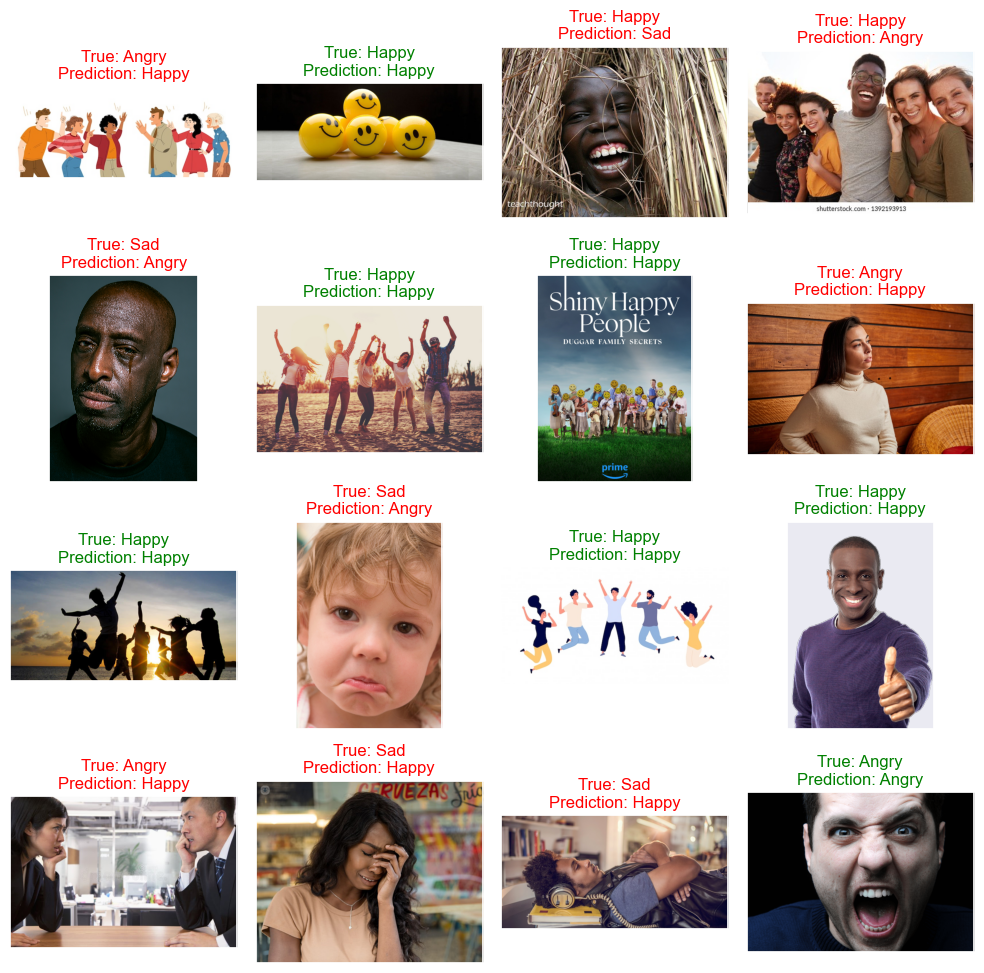

In [57]:
index_random = np.random.choice(len(test), size=min(16, len(test)), replace=False)

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10,10),
                         subplot_kw={'xticks':[], 'yticks':[]})

for i, ax in enumerate(axes.flat):
    idx = index_random[i]
    img = plt.imread(test['Filepath'].iloc[idx])
    ax.imshow(img)

    true_label = test['Label'].iloc[idx]
    pred_label = pred[idx]
    color = 'green' if true_label == pred_label else 'red'

    ax.set_title(f'True: {true_label}\nPrediction: {pred_label}', color=color)

plt.tight_layout()
plt.show()


<small>Визуализация показывает случайные тестовые изображения: зеленый заголовок означает верный прогноз, красный - ошибку. Такой просмотр нужен, чтобы увидеть не только число ошибок, но и их характер: какие эмоции модель путает и насколько эти ошибки визуально объяснимы.</small>


## Резюме


**Краткое описание проекта:** классификация эмоций по изображениям с помощью CNN и VGG16.

**1. Локальные данные:** изображения загружаются из zip-архивов в папке блокнота и распаковываются в `data/`.

**2. Исследование CNN:** сравниваются несколько конфигураций по `batch_size`, числу эпох, оптимизатору, `learning rate`, числу сверточных блоков и числу нейронов Dense-слоя. Лучшая конфигурация выбирается по `val_accuracy` и обучается как финальная CNN.

**3. Тонкая настройка VGG16:** сначала при замороженной базе VGG16 обучается только новая классификационная голова. Затем слои `block5_conv1`, `block5_conv2`, `block5_conv3` размораживаются и дообучаются с меньшим `learning rate`.

**4. Оценка:** `cnn_results` показывает подбор гиперпараметров CNN, а `final_results`, test accuracy/loss и `classification_report` сравнивают финальные модели.
